# FGSM Adversarial Attack Tutorial

Author: Chi-Chi Nwosu

Goal:
- Learn how adversarial examples work
- Understand FGSM attacks
- Connect concepts to Fool the Stoplight

Date: June 2026

In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)

PyTorch version: 2.12.0


## What is a Tensor?

A tensor is the basic data structure used by PyTorch.

It is similar to a NumPy array but can run on GPUs.

In [3]:
import torch

x = torch.tensor([1,2,3,4])

print(x)
print(x.shape)

tensor([1, 2, 3, 4])
torch.Size([4])


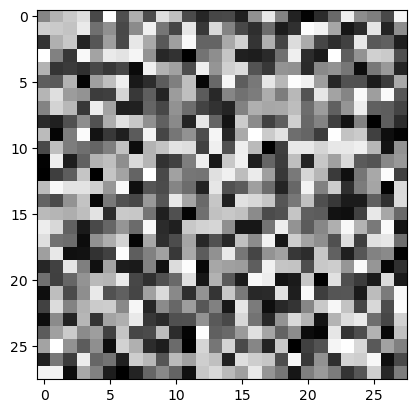

In [4]:
image = torch.rand(28,28)

plt.imshow(image, cmap="gray")
plt.show()


## Key Terms

Dataset:
A collection of images used for training and testing.

Model:
A neural network that makes predictions.

Inference:
Using a trained model to make predictions.

Attack:
An attempt to cause incorrect predictions.

Adversarial Example:
An image that has been intentionally modified to fool a model.

FGSM:
Fast Gradient Sign Method. A simple adversarial attack.

## My Understanding

FGSM changes image pixels slightly.

Humans often cannot notice the changes.

The neural network can be fooled into making incorrect predictions.

## Epsilon

Epsilon controls attack strength.

Small epsilon:
- Small changes
- Harder to notice

Large epsilon:
- Bigger changes
- Easier to fool the model

## Connection to My Research

FGSM modifies pixels directly.

Fool the Stoplight uses adversarial patches.

Both attacks attempt to fool deep learning object detectors.

FGSM is a simpler attack and helps build intuition for adversarial machine learning.

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [6]:
epsilons = [0, .05, .1, .15, .2, .25, .3]
pretrained_model = "data/lenet_mnist_model.pth"
# Set random seed for reproducibility
torch.manual_seed(42)

In [7]:
# LeNet Model definition
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

# MNIST Test dataset and dataloader declaration
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, download=True, transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
            ])),
        batch_size=1, shuffle=True)

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

# Initialize the network
model = Net().to(device)

# Load the pretrained model
model.load_state_dict(torch.load(pretrained_model, map_location=device, weights_only=True))

# Set the model in evaluation mode. In this case this is for the Dropout layers
model.eval()

100%|██████████| 9.91M/9.91M [00:03<00:00, 2.59MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.20MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.01MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.64MB/s]


Using mps device


FileNotFoundError: [Errno 2] No such file or directory: 'data/lenet_mnist_model.pth'

In [8]:
# FGSM attack code
def fgsm_attack(image, epsilon, data_grad):
    # Collect the element-wise sign of the data gradient
    sign_data_grad = data_grad.sign()
    # Create the perturbed image by adjusting each pixel of the input image
    perturbed_image = image + epsilon*sign_data_grad
    # Adding clipping to maintain [0,1] range
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    # Return the perturbed image
    return perturbed_image

# restores the tensors to their original scale
def denorm(batch, mean=[0.1307], std=[0.3081]):
    """
    Convert a batch of tensors to their original scale.

    Args:
        batch (torch.Tensor): Batch of normalized tensors.
        mean (torch.Tensor or list): Mean used for normalization.
        std (torch.Tensor or list): Standard deviation used for normalization.

    Returns:
        torch.Tensor: batch of tensors without normalization applied to them.
    """
    if isinstance(mean, list):
        mean = torch.tensor(mean).to(device)
    if isinstance(std, list):
        std = torch.tensor(std).to(device)

    return batch * std.view(1, -1, 1, 1) + mean.view(1, -1, 1, 1)

In [9]:
def test( model, device, test_loader, epsilon ):

    # Accuracy counter
    correct = 0
    adv_examples = []

    # Loop over all examples in test set
    for data, target in test_loader:

        # Send the data and label to the device
        data, target = data.to(device), target.to(device)

        # Set requires_grad attribute of tensor. Important for Attack
        data.requires_grad = True

        # Forward pass the data through the model
        output = model(data)
        init_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability

        # If the initial prediction is wrong, don't bother attacking, just move on
        if init_pred.item() != target.item():
            continue

        # Calculate the loss
        loss = F.nll_loss(output, target)

        # Zero all existing gradients
        model.zero_grad()

        # Calculate gradients of model in backward pass
        loss.backward()

        # Collect ``datagrad``
        data_grad = data.grad.data

        # Restore the data to its original scale
        data_denorm = denorm(data)

        # Call FGSM Attack
        perturbed_data = fgsm_attack(data_denorm, epsilon, data_grad)

        # Reapply normalization
        perturbed_data_normalized = transforms.Normalize((0.1307,), (0.3081,))(perturbed_data)

        # Re-classify the perturbed image
        output = model(perturbed_data_normalized)

        # Check for success
        final_pred = output.max(1, keepdim=True)[1] # get the index of the max log-probability
        if final_pred.item() == target.item():
            correct += 1
            # Special case for saving 0 epsilon examples
            if epsilon == 0 and len(adv_examples) < 5:
                adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
                adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex) )
        else:
            # Save some adv examples for visualization later
            if len(adv_examples) < 5:
                adv_ex = perturbed_data.squeeze().detach().cpu().numpy()
                adv_examples.append( (init_pred.item(), final_pred.item(), adv_ex) )

    # Calculate final accuracy for this epsilon
    final_acc = correct/float(len(test_loader))
    print(f"Epsilon: {epsilon}\tTest Accuracy = {correct} / {len(test_loader)} = {final_acc}")

    # Return the accuracy and an adversarial example
    return final_acc, adv_examples

In [10]:
accuracies = []
examples = []

# Run test for each epsilon
for eps in epsilons:
    acc, ex = test(model, device, test_loader, eps)
    accuracies.append(acc)
    examples.append(ex)

Epsilon: 0	Test Accuracy = 193 / 10000 = 0.0193
Epsilon: 0.05	Test Accuracy = 154 / 10000 = 0.0154
Epsilon: 0.1	Test Accuracy = 122 / 10000 = 0.0122
Epsilon: 0.15	Test Accuracy = 126 / 10000 = 0.0126
Epsilon: 0.2	Test Accuracy = 105 / 10000 = 0.0105
Epsilon: 0.25	Test Accuracy = 126 / 10000 = 0.0126
Epsilon: 0.3	Test Accuracy = 104 / 10000 = 0.0104


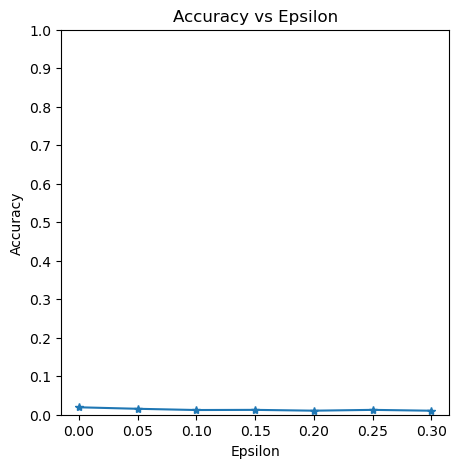

In [11]:
plt.figure(figsize=(5,5))
plt.plot(epsilons, accuracies, "*-")
plt.yticks(np.arange(0, 1.1, step=0.1))
plt.xticks(np.arange(0, .35, step=0.05))
plt.title("Accuracy vs Epsilon")
plt.xlabel("Epsilon")
plt.ylabel("Accuracy")
plt.show()

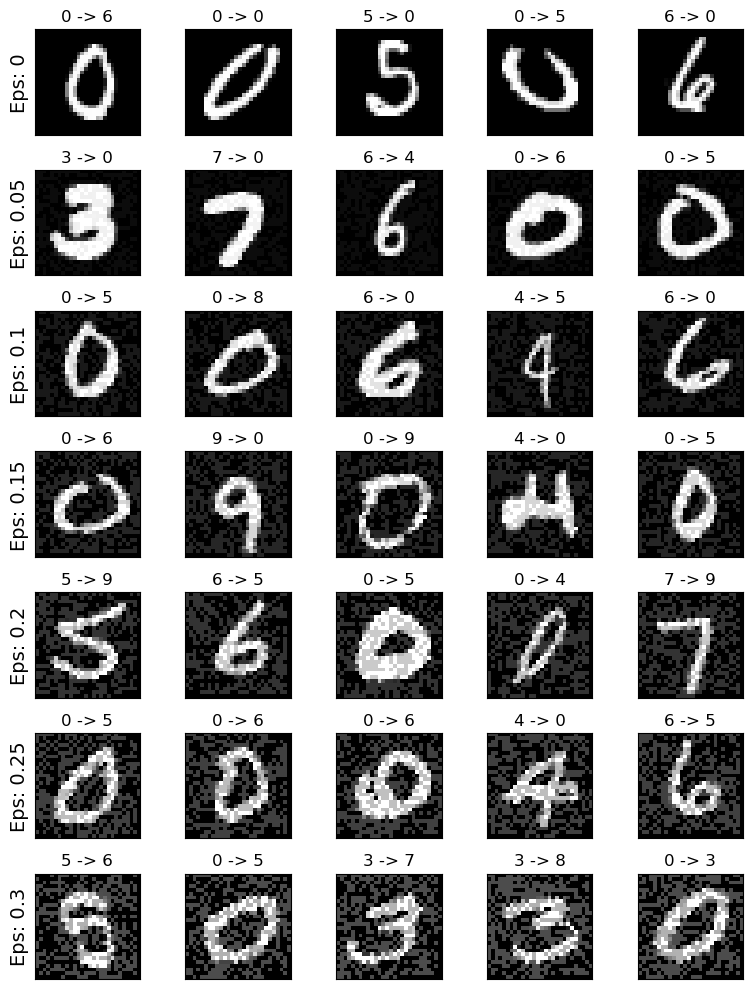

In [12]:
# Plot several examples of adversarial samples at each epsilon
cnt = 0
plt.figure(figsize=(8,10))
for i in range(len(epsilons)):
    for j in range(len(examples[i])):
        cnt += 1
        plt.subplot(len(epsilons),len(examples[0]),cnt)
        plt.xticks([], [])
        plt.yticks([], [])
        if j == 0:
            plt.ylabel(f"Eps: {epsilons[i]}", fontsize=14)
        orig,adv,ex = examples[i][j]
        plt.title(f"{orig} -> {adv}")
        plt.imshow(ex, cmap="gray")
plt.tight_layout()
plt.show()

# FGSM Tutorial Notes

## Key Concepts

### White-Box Attack
The attacker has full access to the model architecture, parameters, and gradients.

### Adversarial Example
An input that has been intentionally modified to cause a machine learning model to make an incorrect prediction.

### FGSM
Fast Gradient Sign Method. An attack that uses the gradient of the loss with respect to the input image to create adversarial examples.

### Epsilon
Controls the strength of the attack.
- Small epsilon = small perturbation
- Large epsilon = stronger attack

### Main Observation
As epsilon increases:
- Model accuracy decreases
- Perturbations become more visible

### Connection to My Research
FGSM modifies image pixels directly using gradients.

The Fool the Stoplight project uses adversarial patches instead of modifying every pixel, but both attacks attempt to fool computer vision models.

FGSM helps build intuition for adversarial machine learning before reproducing traffic-light attack experiments.